# CNN Baseline for Parking Space Classification

This notebook implements a simple CNN classifier to classify parking spaces into three categories:
- **free**: Free parking space
- **not_free**: Occupied parking space  
- **partial**: Partially free parking space

Features:
- Checkpoint saving (best model + periodic checkpoints)
- Early stopping to prevent overfitting
- Training/validation curves
- Confusion matrix and classification report


## 1. Imports & Configuration


In [4]:
import os
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Base paths
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data" / "processed" / "cnn_baseline"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR, "exists:", DATA_DIR.exists())
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)

# Training hyperparameters
BATCH_SIZE = 32
IMG_SIZE = 128   # you can try 64 or 224 later
VAL_SPLIT = 0.2
NUM_EPOCHS = 50  # Increased for early stopping
LEARNING_RATE = 1e-3
RANDOM_SEED = 42

# Early stopping parameters
EARLY_STOPPING_PATIENCE = 10  # Stop if no improvement for 10 epochs
MIN_DELTA = 0.001  # Minimum change to qualify as improvement

# Checkpoint parameters
CHECKPOINT_EVERY = 5  # Save checkpoint every N epochs

# Resume training: If a checkpoint exists, training will automatically resume from the last epoch
# To start fresh, delete the checkpoint files in the checkpoints/ directory
# To continue training beyond the checkpoint, simply increase NUM_EPOCHS

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


BASE_DIR: c:\Harosha\George Brown\DL2\parking-vision
DATA_DIR: c:\Harosha\George Brown\DL2\parking-vision\data\processed\cnn_baseline exists: True
CHECKPOINT_DIR: c:\Harosha\George Brown\DL2\parking-vision\checkpoints
Using device: cpu


## 2. Data Loading and Preprocessing


In [5]:
# Data augmentation and normalization
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

# ImageFolder will infer class names from subfolder names
full_dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=train_transforms)
class_names = full_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names, "| num_classes:", num_classes)
print("Total samples:", len(full_dataset))

# Reproducibility
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Train/val split
val_size = int(VAL_SPLIT * len(full_dataset))
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Important: val_dataset should use val_transforms instead of train_transforms
# random_split keeps a reference to the original dataset, so we patch transforms:
train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_transforms

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


Classes: ['free', 'not_free', 'partial'] | num_classes: 3
Total samples: 903
Train size: 723
Val size: 180


### 2.1 Visualize Sample Images


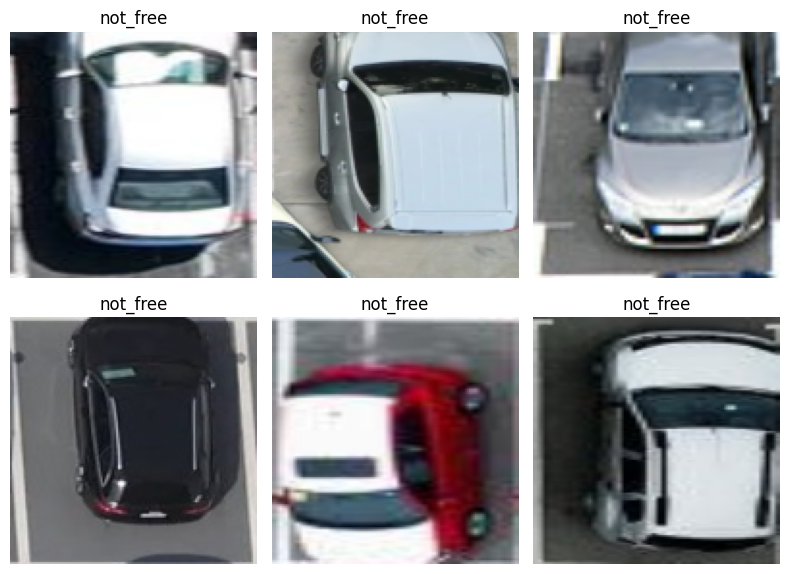

In [6]:
# Visualize a few training images
images, labels = next(iter(train_loader))
images_vis = images[:6].clone()
images_vis = images_vis * 0.5 + 0.5  # de-normalize to [0,1]

fig, axes = plt.subplots(2, 3, figsize=(8, 6))
axes = axes.flatten()
for i in range(6):
    img = images_vis[i].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)  # Ensure valid range
    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i].item()])
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## 3. Model Definition


In [7]:
class SimpleParkingCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # For IMG_SIZE = 128:
        # 128 -> pool -> 64 -> pool -> 32 -> pool -> 16
        conv_output_size = 64 * (IMG_SIZE // 8) * (IMG_SIZE // 8)

        self.fc1 = nn.Linear(conv_output_size, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 128 -> 64
        x = self.pool(F.relu(self.conv2(x)))  # 64 -> 32
        x = self.pool(F.relu(self.conv3(x)))  # 32 -> 16

        x = torch.flatten(x, 1)  # (batch, features)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = SimpleParkingCNN(num_classes=num_classes).to(device)
print(model)

# Check parameter count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")


SimpleParkingCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)

Trainable parameters: 2,121,251


## 4. Training Setup


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)


### 5.0 Optional: Reset Checkpoints (Start Fresh)

Run this cell only if you want to delete all checkpoints and start training from scratch.


In [9]:
# Uncomment the lines below to delete all checkpoints and start fresh
# import shutil
# if CHECKPOINT_DIR.exists():
#     for checkpoint_file in CHECKPOINT_DIR.glob("*.pt"):
#         checkpoint_file.unlink()
#         print(f"Deleted: {checkpoint_file.name}")
#     print("All checkpoints deleted. Training will start from scratch.")
# else:
#     print("No checkpoints directory found.")

print("Checkpoint reset is disabled. Uncomment the code above to enable.")


Checkpoint reset is disabled. Uncomment the code above to enable.


## 5. Training Loop with Early Stopping, Checkpoints, and Resume

**Resume Functionality**: If a checkpoint exists, training will automatically resume from the last saved epoch. Simply increase `NUM_EPOCHS` to continue training beyond the checkpoint. To start fresh, delete the checkpoint files.


In [10]:
# Check for existing checkpoints to resume training
start_epoch = 1
best_val_acc = 0.0
best_val_loss = float('inf')
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}
patience_counter = 0
best_epoch = 0

# Try to load the best model checkpoint first (most recent training)
best_model_path = CHECKPOINT_DIR / "best_model.pt"
if best_model_path.exists():
    print(f"Found existing checkpoint: {best_model_path}")
    checkpoint = torch.load(best_model_path, map_location=device)
    
    # Load model state
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Restore training state
    start_epoch = checkpoint['epoch'] + 1
    # Use best_val_acc from checkpoint if available, otherwise use current val_acc
    best_val_acc = checkpoint.get('best_val_acc', checkpoint['val_acc'])
    best_val_loss = checkpoint.get('val_loss', checkpoint.get('best_val_loss', float('inf')))
    best_epoch = checkpoint.get('best_epoch', checkpoint['epoch'])
    history = checkpoint.get('history', history)
    
    # Restore patience counter if available
    patience_counter = checkpoint.get('patience_counter', 0)
    
    print(f"Resuming training from epoch {start_epoch}")
    print(f"Previous best: Val Acc = {best_val_acc:.4f} at epoch {best_epoch}")
    print(f"Previous history: {len(history['train_loss'])} epochs completed")
    
    # If we're already past NUM_EPOCHS, inform user
    if start_epoch > NUM_EPOCHS:
        print(f"\nNote: Checkpoint is at epoch {start_epoch-1}, but NUM_EPOCHS={NUM_EPOCHS}.")
        print("Increase NUM_EPOCHS to continue training beyond the checkpoint.")
else:
    print("No existing checkpoint found. Starting fresh training.")

start_time = time.time()

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Check for improvement
    improved = False
    if val_acc > best_val_acc + MIN_DELTA:
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        improved = True
        
        # Save best model
        best_model_path = CHECKPOINT_DIR / "best_model.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,  # Current epoch's val_acc (which is now the best)
            'val_loss': val_loss,
            'best_val_acc': best_val_acc,  # Explicitly save best_val_acc
            'best_val_loss': best_val_loss,
            'best_epoch': best_epoch,
            'patience_counter': patience_counter,
            'history': history,
        }, best_model_path)
        print(f"  -> New best model saved! (Val Acc: {val_acc:.4f})")
    else:
        patience_counter += 1

    # Periodic checkpoint (every N epochs)
    if epoch % CHECKPOINT_EVERY == 0:
        checkpoint_path = CHECKPOINT_DIR / f"checkpoint_epoch_{epoch}.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'best_epoch': best_epoch,
            'best_val_acc': best_val_acc,
            'patience_counter': patience_counter,
            'history': history,
        }, checkpoint_path)
        print(f"  -> Checkpoint saved: {checkpoint_path.name}")

    print(
        f"Epoch [{epoch}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        f"{' *' if improved else ''}"
    )

    # Early stopping check
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered! No improvement for {EARLY_STOPPING_PATIENCE} epochs.")
        print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")
        break

end_time = time.time()
print(f"\nTraining finished in {(end_time - start_time)/60:.2f} minutes.")
print(f"Best val acc: {best_val_acc:.4f} at epoch {best_epoch}")
print(f"Total epochs trained: {epoch}")
print(f"\nTo resume training, increase NUM_EPOCHS and rerun this cell.")
print(f"The training will automatically resume from epoch {epoch + 1}.")


No existing checkpoint found. Starting fresh training.
  -> New best model saved! (Val Acc: 0.9278)
Epoch [1/50] Train Loss: 0.4474 | Train Acc: 0.8077 | Val Loss: 0.1821 | Val Acc: 0.9278 *
  -> New best model saved! (Val Acc: 0.9500)
Epoch [2/50] Train Loss: 0.1594 | Train Acc: 0.9447 | Val Loss: 0.1507 | Val Acc: 0.9500 *
Epoch [3/50] Train Loss: 0.1227 | Train Acc: 0.9682 | Val Loss: 0.1852 | Val Acc: 0.9111
  -> New best model saved! (Val Acc: 0.9556)
Epoch [4/50] Train Loss: 0.1026 | Train Acc: 0.9627 | Val Loss: 0.1296 | Val Acc: 0.9556 *
  -> Checkpoint saved: checkpoint_epoch_5.pt
Epoch [5/50] Train Loss: 0.0888 | Train Acc: 0.9723 | Val Loss: 0.1559 | Val Acc: 0.9444
  -> New best model saved! (Val Acc: 0.9611)
Epoch [6/50] Train Loss: 0.0649 | Train Acc: 0.9862 | Val Loss: 0.1273 | Val Acc: 0.9611 *
Epoch [7/50] Train Loss: 0.0704 | Train Acc: 0.9751 | Val Loss: 0.1296 | Val Acc: 0.9556
Epoch [8/50] Train Loss: 0.0629 | Train Acc: 0.9820 | Val Loss: 0.1342 | Val Acc: 0.9444


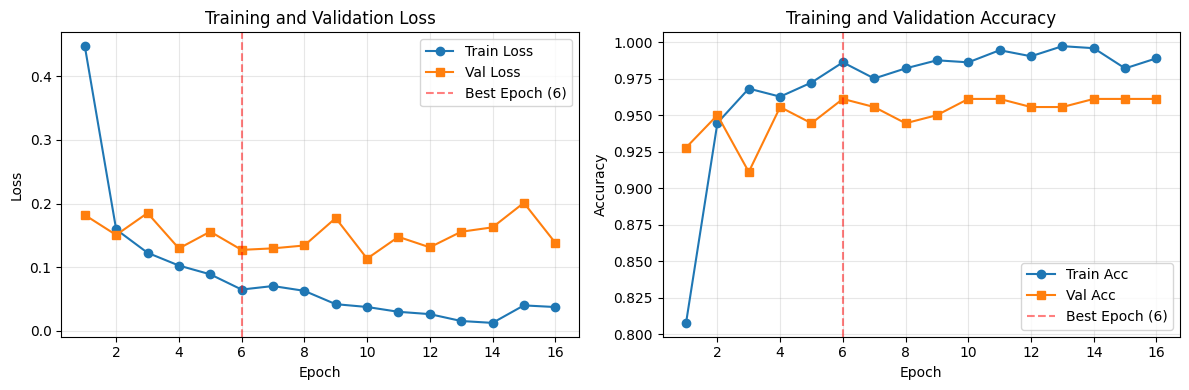

In [11]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss", marker='o')
plt.plot(epochs, history["val_loss"], label="Val Loss", marker='s')
plt.axvline(x=best_epoch, color='r', linestyle='--', alpha=0.5, label=f'Best Epoch ({best_epoch})')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train Acc", marker='o')
plt.plot(epochs, history["val_acc"], label="Val Acc", marker='s')
plt.axvline(x=best_epoch, color='r', linestyle='--', alpha=0.5, label=f'Best Epoch ({best_epoch})')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Evaluation on Best Model


In [12]:
# Load the best model
best_model = SimpleParkingCNN(num_classes=num_classes).to(device)
checkpoint = torch.load(CHECKPOINT_DIR / "best_model.pt", map_location=device)
best_model.load_state_dict(checkpoint['model_state_dict'])

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best validation accuracy: {checkpoint['val_acc']:.4f}")

# Evaluate on validation set
val_loss, val_acc, y_true, y_pred = evaluate(best_model, val_loader, criterion, device)
print(f"\nBest model on val set -> Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")


C:\Users\haros\AppData\Local\Temp\ipykernel_37288\2971234433.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_DIR / "best_model.pt", ma

Loaded best model from epoch 6
Best validation accuracy: 0.9611

Best model on val set -> Loss: 0.1273, Acc: 0.9611


### 7.1 Confusion Matrix


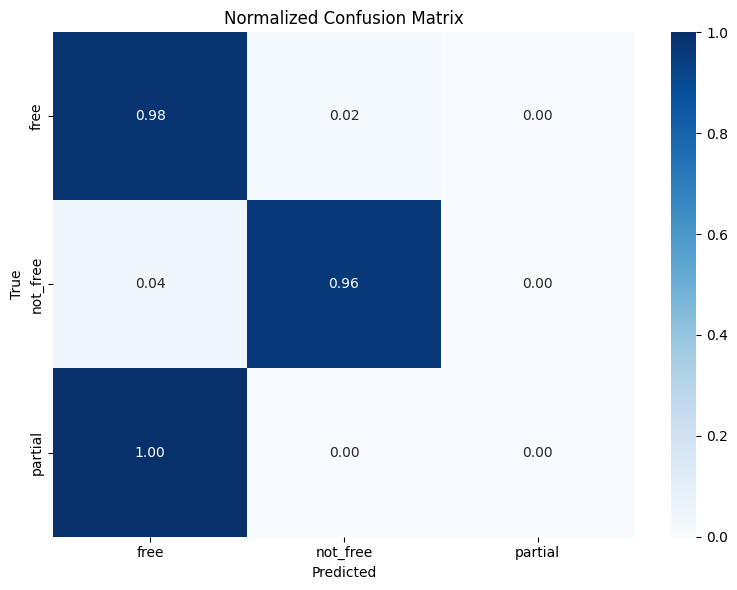

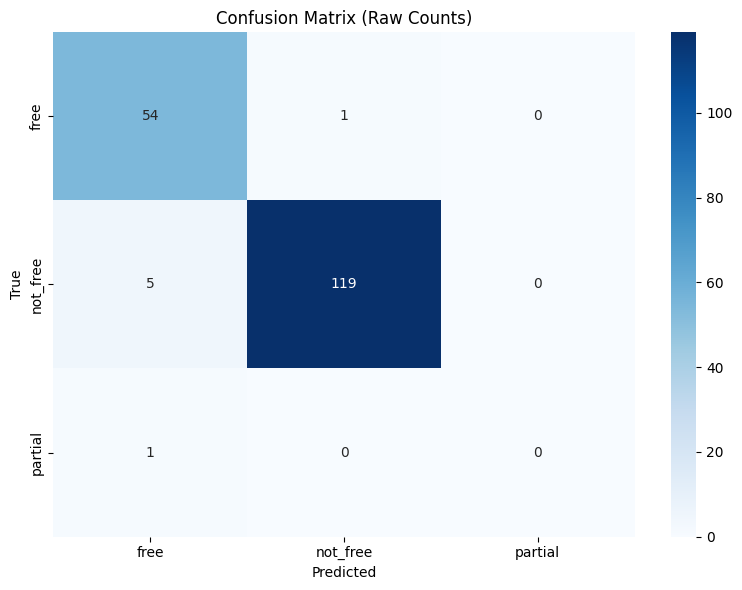

In [13]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

# Also show raw counts
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Raw Counts)")
plt.tight_layout()
plt.show()


### 7.2 Classification Report


In [14]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:

              precision    recall  f1-score   support

        free       0.90      0.98      0.94        55
    not_free       0.99      0.96      0.98       124
     partial       0.00      0.00      0.00         1

    accuracy                           0.96       180
   macro avg       0.63      0.65      0.64       180
weighted avg       0.96      0.96      0.96       180



c:\Harosha\George Brown\DL2\parking-vision\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Harosha\George Brown\DL2\parking-vision\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Harosha\George Brown\DL2\parking-vision\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

## 8. Summary

The CNN baseline model has been trained with the following features:

- **Checkpoint Saving**: Best model automatically saved when validation accuracy improves
- **Periodic Checkpoints**: Checkpoints saved every 5 epochs for recovery
- **Early Stopping**: Training stops if no improvement for 10 epochs
- **Training History**: Complete training and validation metrics tracked
- **Evaluation Metrics**: Confusion matrix and classification report generated

All checkpoints are saved in the `checkpoints/` directory.
